# Abstract

This study investigates what factors affect an online gamer's anxiety level, using the Online Gaming Anxiety dataset of over 13,000 survey responses collected from gaming communities. After filtering to League of Legends players and cleaning the data (handling nulls, outliers, and inconsistent text categories), we explore anxiety (`GAD_T`) alongside social anxiety (`SPIN_T`), life satisfaction (`SWL_T`), and weekly hours played (`Hours`). Initial exploratory analysis shows anxiety scores are right-skewed and moderately correlated with social anxiety and life satisfaction, but only weakly related to hours played. These early findings will guide the statistical testing and data mining planned for MCO2.

# Dataset Description

### General Description

The Online Gaming Anxiety Dataset is a large-scale public dataset compiled by researchers __Marian Sauter__ and __Dejan Draschkow__ (2017). It was designed to empirically investigate the relationship between online video gaming behaviors (e.g., playtimes, social contexts, motivations) and mental health indicators—specifically generalized anxiety, social phobia, and overall life satisfaction.

### How the Dataset was Collected

- __Method:__ The researchers used an _online survey/questionnaire_ hosted on the Open Science Framework (OSF)

- __Recruitment:__ Convenience sampling was employed by posting invitations containing the links to the survey across online gaming communities and forums such as `r/gaming`, `r/leagueoflegends`.

### Potential Implications of Data Collection on Generated Insights

- **Self-Selection Bias:** Voluntary participation may have attracted gamers with strong opinions or higher psychological distress.
- **Community Bias:** Recruitment through gaming forums likely overrepresents hardcore/competitive players and underrepresents casual or mobile-first gamers.
- **Self-Reporting Bias:** Playtime and stream-watching hours are self-reported and may be inaccurately estimated; psychological scores may carry social desirability bias.
- **No Control Group:** Since only active gamers were surveyed, there is no non-gamer baseline for comparison.

These biases mean conclusions apply mainly to active, forum-engaged gamers, not gamers in general.

### Structure of the Data

- __Representation__
> - __Rows:__ Each row represents a single, anonymous response.
> - __Columns:__ Each column respresents a specific attribute including demographics, gaming behaviors, or an aggregated clinical scale.

- __Number of Observations__
> - __Original Dataset:__ Contains `13,464` entries across `55` columns.
> - __Cleaned Dataset:__ Contains `12,562` entries across `19` standardized columns after dropping metadata, individual questionnaire items, null values, and outliers with weekly playtime `>100 hours`.

### Attribute Dictionary

**1. Demographic Attributes**
- `Age:` Numeric, respondent's age (18-56 years).
- `Gender:` Categorical, gender identity (Male, Female, Other).
- `Degree:` Categorical, highest educational attainment.
- `Work:` Categorical, employment status (Employed, Unemployed, Student).
- `Birthplace` & `Residence:` Categorical, country of birth and current residence.

**2. Gaming Behavior & Motivation Attributes**
- `Hours:` Numeric, average weekly hours playing (max 100).
- `streams:` Numeric, average weekly hours watching game streams.
- `Platform:` Categorical, primary gaming system (PC, Console, Mobile).
- `Playstyle:` Categorical, social setting of play (solo, with online/offline friends, strangers).
- `League:` Categorical, competitive rank tier (Master+ to Bronze, Unranked).
- `whyplay:` Categorical, main reason for playing (fun, improving, winning, relaxing, escapism, other).
- `earnings:` Categorical, plays for fun vs. financial compensation.
- `Game:` Categorical, primary game played.

**3. Clinical & Psychological Attributes (Aggregated)**
- `GAD_T:` Numeric, total GAD-7 anxiety score (0-21; higher = more anxious).
- `SWL_T:` Numeric, total life satisfaction score, SWLS scale (5-35; higher = more satisfied).
- `SPIN_T:` Numeric, total social anxiety score, SPIN scale (0-68; higher = more severe).
- `GADE:` Categorical, how much anxiety affects daily life/work.
- `Narcissism:` Numeric, self-reported single-item score (1-5).

Individual item-level columns (`GAD1-7`, `SWL1-5`, `SPIN1-17`) were dropped in favor of these totals.

## Import required modules and download csv file.

In [25]:
import kagglehub
import polars as pl
import os
path = kagglehub.dataset_download("divyansh22/online-gaming-anxiety-data")

print("Path to dataset files:", path)
csv = os.path.join(path, "GamingStudy_data.csv")
df = pl.read_csv(csv, encoding="latin1", null_values="NA")

Using Colab cache for faster access to the 'online-gaming-anxiety-data' dataset.
Path to dataset files: /kaggle/input/online-gaming-anxiety-data


# Data Cleaning and Preprocessing

In [26]:
pl.Config.set_tbl_rows(-1)        # Show all rows
pl.Config.set_tbl_cols(-1)        # Show all columns
pl.Config.set_tbl_width_chars(-1) # Use full terminal width
df.describe()

statistic,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,highestleague,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,str,str,str,str,str,str,f64,f64,f64,str,str
"""count""",13464.0,13464.0,13464.0,13464.0,13464.0,13464.0,13464.0,13464.0,13464.0,"""12815""",13464.0,13464.0,13464.0,13464.0,13464.0,"""13464""","""13464""",13434.0,"""13464""","""13464""","""11719""","""0""",13364.0,13340.0,13310.0,13324.0,13305.0,13298.0,13308.0,13326.0,13320.0,13306.0,13304.0,13277.0,13296.0,13277.0,13308.0,13317.0,13317.0,13289.0,13441.0,"""13464""",13464.0,"""13426""","""13464""","""13464""","""13464""","""13449""","""13464""","""13050""",13464.0,13464.0,12814.0,"""13354""","""13343"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""649""",0.0,0.0,0.0,0.0,0.0,"""0""","""0""",30.0,"""0""","""0""","""1745""","""13464""",100.0,124.0,154.0,140.0,159.0,166.0,156.0,138.0,144.0,158.0,160.0,187.0,168.0,187.0,156.0,147.0,147.0,175.0,23.0,"""0""",0.0,"""38""","""0""","""0""","""0""","""15""","""0""","""414""",0.0,0.0,650.0,"""110""","""121"""
"""mean""",7096.839201,42054.841222,0.860963,0.673351,0.965761,0.724079,0.488042,0.911022,0.588755,null,3.72044,4.60205,4.34544,3.762032,3.358883,null,null,22.247357,null,null,null,null,11.233538,0.856897,1.210969,1.095392,1.682976,1.248985,1.348287,1.050503,1.40503,1.567338,0.917769,1.827446,0.892148,0.538827,1.252405,1.411054,0.620635,0.935962,2.027677,null,20.930407,null,null,null,null,null,null,null,5.211973,19.788844,19.848525,null,null
"""std""",4114.47822,0.272948,0.926542,0.915724,0.982776,0.921971,0.837014,0.931168,0.894408,null,1.736264,1.696276,1.80943,1.818136,1.916319,null,null,70.284502,null,null,null,null,78.549209,0.907351,1.144054,1.164982,1.22973,1.221828,1.279251,1.221171,1.372777,1.383539,1.125849,1.488372,1.158235,0.94418,1.207463,1.349874,0.961853,1.180456,1.061842,null,3.300897,null,null,null,null,null,null,null,4.713267,7.229243,13.467493,null,null
"""min""",1.0,42052.00437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Extremely difficult""",1.0,1.0,1.0,1.0,1.0,"""Counter Strike""","""Console (PS, Xbox, ...)""",0.0,""" play for fun at the moment, b…","""1. Having fun 2. winning 3. im…",""" """,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Female""",18.0,"""Employed""","""Bachelor (or equivalent)""","""Afghanistan""","""Albania""","""CrowdFlower""",""" Multiplayer - online - with f…","""Accept""",0.0,5.0,0.0,"""ALB""","""AFG"""
"""25%""",3533.0,42054.71655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,2.0,3.0,3.0,2.0,2.0,null,null,12.0,null,null,null,null,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,null,18.0,null,null,null,null,null,null,null,2.0,14.0,9.0,null,null
"""50%""",7088.0,42054.80069,1.0,0.0,1.0,0.0,0.0,1.0,0.0,null,4.0,5.0,5.0,4.0,3.0,null,null,20.0,null,null,null,null,8.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,null,20.0,null,null,null,null,null,null,null,4.0,20.0,17.0,null,null
"""75%""",10654.0,42054.93211,1.0,1.0,2.0,1.0,1.0,1.0,1.0,null,5.0,6.0,6.0,5.0,5.0,null,null,28.0,null,null,null,null,15.0,1.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,1.0,1.0,2.0,2.0,1.0,2.0,3.0,null,22.0,null,null,null,null,null,null,null,8.0,26.0,28.0,null,null
"""max""",14250.0,42058.36375,3.0,3.0,3.0,3.0,3.0,3.0,3.0,"""Very difficult""",7.0,7.0,7.0,7.0,7.0,"""World of Warcraft""","""Smartphone / Tablet""",8000.0,"""working towards getting some f…","""winning/improving/and having f…","""~plat""",null,9001.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0

## Drop Unnecessary Columns
These columns were dropped as this study will utilize the aggregate variables rather than individual questionnaire items:
- `S. No.` & `Timestamp` (not useful for statistical modeling)
- `GAD1` to `GAD7` (redundant, represented by the total score `GAD_T`)
- `SWL1` to `SWL5` (redundant, represented by `SWL_T`)
- `SPIN1` to `SPIN17` (redundant, represented by `SPIN_T`)
- `highestleague` (100% null/missing values)
- `Residence_ISO3` & `Birthplace_ISO3` (redundant, represented by `Residence` and `Birthplace` respectively)
- `accept` (participant consent column, contains no predictive information for modeling)
- `reference` (contains no predictive information for modeling)

In [27]:
dropped_columns = [
    "S. No.", "Timestamp", "GAD1", "GAD2", "GAD3", "GAD4", "GAD5", "GAD6", "GAD7",
    "SWL1", "SWL2", "SWL3", "SWL4", "SWL5", "SPIN1", "SPIN2", "SPIN3", "SPIN4",
    "SPIN5", "SPIN6", "SPIN7", "SPIN8", "SPIN9", "SPIN10", "SPIN11", "SPIN12",
    "SPIN13", "SPIN14", "SPIN15", "SPIN16", "SPIN17", "highestleague",
    "Residence_ISO3", "Birthplace_ISO3", "accept", "Reference"
]

df_clean = df.drop(dropped_columns)
df_clean.head()
df_clean["Game"].value_counts()

Game,count
str,u32
"""Starcraft 2""",345
"""Guild Wars 2""",37
"""League of Legends""",11314
"""Heroes of the Storm""",41
"""Diablo 3""",89
"""Other""",1021
"""Hearthstone""",101
"""Destiny""",18
"""Counter Strike""",318


## Scoping Down to Players Who Only Play League of Legends
Since this study will only consider league of legends players. We filter out everybody else.

In [28]:
df_clean = df_clean.filter(pl.col("Game") == "League of Legends")

## Outlier Treatment

Drop unrealistic values in the `Hours` column (participants reporting >=100 hours of gaming per week).

In [47]:
df_clean["Hours"].describe()

statistic,value
str,f64
"""count""",10584.0
"""null_count""",0.0
"""mean""",21.245748
"""std""",12.838746
"""min""",0.0
"""25%""",12.0
"""50%""",20.0
"""75%""",28.0
"""max""",96.0


In [48]:
df_clean = df_clean.filter(pl.col("Hours") < 100)
df_clean.shape

(10584, 19)

# Null Cleaning
Each column was checked for null values. Whether to drop or impute nulls was decided based on the proportion and nature of the missingness.

In [31]:
df_clean.null_count()

GADE,Game,Platform,Hours,earnings,whyplay,League,streams,Narcissism,Gender,Age,Work,Degree,Birthplace,Residence,Playstyle,GAD_T,SWL_T,SPIN_T
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
533,0,0,0,0,0,1161,75,19,0,0,33,0,0,0,0,0,0,540


### Null Value Imputation and Dropping

1. **GADE (How gaming affects daily life/work)**: The `GADE` question is optional in the official GAD questionnaire and is skipped if the participant has zero anxiety. Therefore, we impute missing `GADE` values as `"Not difficult at all"` if `GAD_T == 0`. The remaining null values for `GADE` (where `GAD_T > 0`) are dropped.
2. **Other Nulls**: We drop rows containing null values for `Narcissism`, `streams`, `Work`, and `SPIN_T` as they represent a small percentage of the dataset.

In [32]:
# Impute GADE as 'Not difficult at all' when GAD_T is 0
df_clean = df_clean.with_columns(
    pl.when(pl.col("GADE").is_null() & (pl.col("GAD_T") == 0))
    .then(pl.lit("Not difficult at all"))
    .otherwise(pl.col("GADE"))
    .alias("GADE")
)

# Drop remaining nulls across key columns
df_clean = df_clean.drop_nulls(["Narcissism", "streams", "Work", "GADE", "SPIN_T"])
df_clean.shape

(10597, 19)

*Take note the "Work" column includes unemployed, students and employment so there's no valid reason to have it as null*

## Standardizing the League and whyplay Columns

The `League` and `whyplay` columns are free-text fields containing typos and inconsistent entries, so we standardize them into discrete categories.

#### League Rank Standardization
- **Master+:** Challenger, Master, Grandmaster, GM, and typos (e.g. *challenjour*).
- **Diamond:** Diamond, Dia, abbreviations (*d1*-*d5*).
- **Platinum:** Platinum, Plat, and misspellings.
- **Gold:** Gold and typos (*glod*, *golld*).
- **Silver:** Silver and misspellings (*sliver*, *siver*).
- **Bronze:** Bronze and misspellings (*bronce*, *broze*).
- **Unranked:** Blank/unranked responses, non-League ranks, and noise.

#### whyplay (Reason for Playing) Standardization
- **Having Fun:** Joy, pleasure, fun-related motivations.
- **Improving:** Skill progression and learning.
- **Winning:** Competition, victory, rank-climbing.
- **Relaxing:** De-stressing, casual play.
- **Mixed / All:** Custom responses citing multiple reasons.
- **Escapism:** Passing time, distraction from reality.
- **Other:** Custom/uncategorized answers.

In [33]:
df_clean = df_clean.with_columns(pl.col("whyplay").str.to_lowercase())
df_clean = df_clean.with_columns(pl.col("League").str.to_lowercase())

In [34]:
# Apply simplified Polars mapping expressions
league_lower = pl.col("League").fill_null("unranked").str.to_lowercase()

df_clean = df_clean.with_columns(
    pl.when(league_lower.str.contains(r"master|grandmaster|challenger|gm"))
    .then(pl.lit("Master+"))
    .when(league_lower.str.contains(r"diamond|dia|\bd[1-5]\b"))
    .then(pl.lit("Diamond"))
    .when(league_lower.str.contains(r"platinum|plat|\bp[1-5]\b"))
    .then(pl.lit("Platinum"))
    .when(league_lower.str.contains(r"gold|\bg[1-5]\b"))
    .then(pl.lit("Gold"))
    .when(league_lower.str.contains(r"silver|\bs[1-5]\b"))
    .then(pl.lit("Silver"))
    .when(league_lower.str.contains(r"bronze|\bb[1-5]\b"))
    .then(pl.lit("Bronze"))
    .otherwise(pl.lit("Unranked"))
    .alias("League_Standardized")
)

# Standardize whyplay
wp_lower = pl.col("whyplay").fill_null("other").str.to_lowercase()

has_fun = wp_lower.str.contains("fun")
has_improv = wp_lower.str.contains("improv")
has_win = wp_lower.str.contains("win")
has_relax = wp_lower.str.contains("relax")
has_escapism = wp_lower.str.contains("escap|distract|forget|time")

is_mixed = wp_lower.str.contains("all|both|mix") | (
    (has_fun.cast(pl.Int32) + has_improv.cast(pl.Int32) + has_win.cast(pl.Int32) + has_relax.cast(pl.Int32)) > 1
)

df_clean = df_clean.with_columns(
    pl.when(is_mixed)
    .then(pl.lit("Mixed / All"))
    .when(has_fun)
    .then(pl.lit("Having Fun"))
    .when(has_improv)
    .then(pl.lit("Improving"))
    .when(has_win)
    .then(pl.lit("Winning"))
    .when(has_relax)
    .then(pl.lit("Relaxing"))
    .when(has_escapism)
    .then(pl.lit("Escapism"))
    .otherwise(pl.lit("Other"))
    .alias("whyplay_Standardized")
)

print(df_clean.select(["League", "League_Standardized"]).head(5))
print(df_clean.select(["whyplay", "whyplay_Standardized"]).head(5))


shape: (5, 2)
┌────────────────────┬─────────────────────┐
│ League             ┆ League_Standardized │
│ ---                ┆ ---                 │
│ str                ┆ str                 │
╞════════════════════╪═════════════════════╡
│ gold               ┆ Gold                │
│ bronze             ┆ Bronze              │
│ silver 4           ┆ Silver              │
│ gold               ┆ Gold                │
│ unranked - low elo ┆ Unranked            │
└────────────────────┴─────────────────────┘
shape: (5, 2)
┌────────────┬──────────────────────┐
│ whyplay    ┆ whyplay_Standardized │
│ ---        ┆ ---                  │
│ str        ┆ str                  │
╞════════════╪══════════════════════╡
│ having fun ┆ Having Fun           │
│ having fun ┆ Having Fun           │
│ improving  ┆ Improving            │
│ having fun ┆ Having Fun           │
│ improving  ┆ Improving            │
└────────────┴──────────────────────┘


In [35]:
# Save original vs standardized column mappings to an editable text file
with pl.Config(tbl_rows=-1, fmt_str_lengths=1000, tbl_width_chars=10000):
    league_mapping = str(df_clean.group_by(["League", "League_Standardized"]).len().sort("len", descending=True))
    whyplay_mapping = str(df_clean.group_by(["whyplay", "whyplay_Standardized"]).len().sort("len", descending=True))

# Drop the original columns as they won't be needed anymore
df_clean.drop_in_place("League")
df_clean.drop_in_place("whyplay")

with open("standardization_output.txt", "w", encoding="utf-8") as f:
    f.write("=== ORIGINAL LEAGUE vs STANDARDIZED LEAGUE ===\n")
    f.write(league_mapping)
    f.write("\n\n=== ORIGINAL WHYPLAY vs STANDARDIZED WHYPLAY ===\n")
    f.write(whyplay_mapping)

# Save aggregate (overall distribution) of standardized columns to a separate file
with pl.Config(tbl_rows=-1, fmt_str_lengths=1000, tbl_width_chars=10000):
    league_aggregate = str(df_clean["League_Standardized"].value_counts(sort=True))
    whyplay_aggregate = str(df_clean["whyplay_Standardized"].value_counts(sort=True))

with open("standardization_aggregate.txt", "w", encoding="utf-8") as f:
    f.write("=== AGGREGATE STANDARDIZED LEAGUE COUNTS ===\n")
    f.write(league_aggregate)
    f.write("\n\n=== AGGREGATE STANDARDIZED WHYPLAY COUNTS ===\n")
    f.write(whyplay_aggregate)

In [36]:
df_clean.describe()

statistic,GADE,Game,Platform,Hours,earnings,streams,Narcissism,Gender,Age,Work,Degree,Birthplace,Residence,Playstyle,GAD_T,SWL_T,SPIN_T,League_Standardized,whyplay_Standardized
str,str,str,str,f64,str,f64,f64,str,f64,str,str,str,str,str,f64,f64,f64,str,str
"""count""","""10597""","""10597""","""10597""",10597.0,"""10597""",10597.0,10597.0,"""10597""",10597.0,"""10597""","""10597""","""10597""","""10597""","""10597""",10597.0,10597.0,10597.0,"""10597""","""10597"""
"""null_count""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0"""
"""mean""",null,null,null,21.342361,null,10.522789,2.022082,null,20.834576,null,null,null,null,null,5.187978,19.840993,19.743324,null,null
"""std""",null,null,null,13.123689,null,10.168567,1.058092,null,3.156438,null,null,null,null,null,4.673519,7.189745,13.386069,null,null
"""min""","""Extremely difficult""","""League of Legends""","""Console (PS, Xbox, ...)""",0.0,""" play for fun at the moment, b…",0.0,1.0,"""Female""",18.0,"""Employed""","""Bachelor (or equivalent)""","""Afghanistan""","""Albania""",""" Multiplayer - online - with f…",0.0,5.0,0.0,"""Bronze""","""Escapism"""
"""25%""",null,null,null,12.0,null,4.0,1.0,null,18.0,null,null,null,null,null,2.0,14.0,9.0,null,null
"""50%""",null,null,null,20.0,null,8.0,2.0,null,20.0,null,null,null,null,null,4.0,20.0,17.0,null,null
"""75%""",null,null,null,28.0,null,15.0,3.0,null,22.0,null,null,null,null,null,8.0,26.0,28.0,null,null
"""max""","""Very difficult""","""League of Legends""","""Smartphone / Tablet""",100.0,"""working towards getting some f…",200.0,5.0,"""Other""",56.0,"""Unemployed / between jobs""","""Ph.D., Psy. D., MD (or equival…","""Zimbabwe""","""Vietnam""","""with strangers and with my fri…",21.0,35.0,68.0,"""Unranked""","""Winning"""


# Research Question & Exploratory Data Analysis

## General Research Question

**What factors affect an online gamer's anxiety level (`GAD_T`)?**

This question was approved by our instructor and was deliberately kept broad rather than narrowed to a single variable pair, since it warrants exploring multiple demographic, behavioral, and psychological variables instead of just one relationship. It is answerable from this dataset because `GAD_T` and plausible related variables (`SPIN_T`, `SWL_T`, `Hours`) are all directly measured. We expect to refine this question further as our EDA and later statistical testing progress.

## setup Polars to Pandas

In [37]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_pd = df_clean.to_pandas()

numeric_cols = ["Hours", "GAD_T", "SPIN_T", "SWL_T"]

print("Dataset Shape:", df_pd.shape)
df_pd[numeric_cols].head()

Dataset Shape: (10597, 19)


,Hours,GAD_T,SPIN_T,SWL_T
0,25,0,3,33
1,5,5,31,26
2,9,0,39,26
3,7,1,29,21
4,25,11,17,10


### EDA Question 1: How is anxiety severity distributed among League of Legends players?

We start by summarizing the central tendency and spread of `GAD_T`, alongside related variables `Hours`, `SPIN_T`, and `SWL_T`, to understand typical anxiety levels before looking at relationships between variables.

## Measures of Central Tendency

In [38]:
# Mean
mean_values = df_pd[numeric_cols].mean()
print("MEAN VALUES\n", mean_values)

# Median
median_values = df_pd[numeric_cols].median()
print("\nMEDIAN VALUES\n", median_values)

# Summary statistics
df_pd[numeric_cols].describe().T

MEAN VALUES
 Hours     21.342361
GAD_T      5.187978
SPIN_T    19.743324
SWL_T     19.840993
dtype: float64

MEDIAN VALUES
 Hours     20.0
GAD_T      4.0
SPIN_T    17.0
SWL_T     20.0
dtype: float64


,count,mean,std,min,25%,50%,75%,max
Hours,10597.0,21.342361,13.123689,0.0,12.0,20.0,28.0,100.0
GAD_T,10597.0,5.187978,4.673519,0.0,2.0,4.0,8.0,21.0
SPIN_T,10597.0,19.743324,13.386069,0.0,9.0,17.0,28.0,68.0
SWL_T,10597.0,19.840993,7.189745,5.0,14.0,20.0,26.0,35.0


**Interpretation:** The mean `GAD_T` score is about 5.19, while the median is 4. Since the mean exceeds the median, the anxiety distribution is right-skewed: most players report low-to-moderate anxiety, but a smaller group reports much higher scores, pulling the average up.

### Visualization (distribution check)

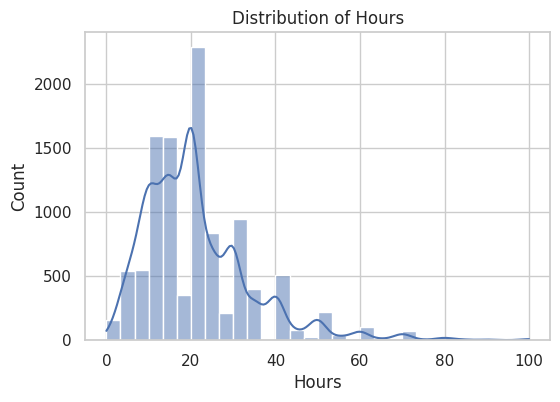

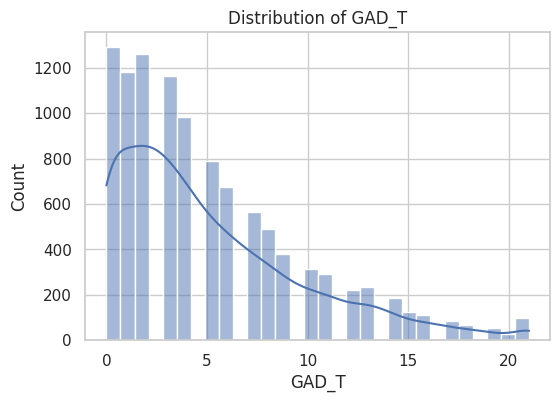

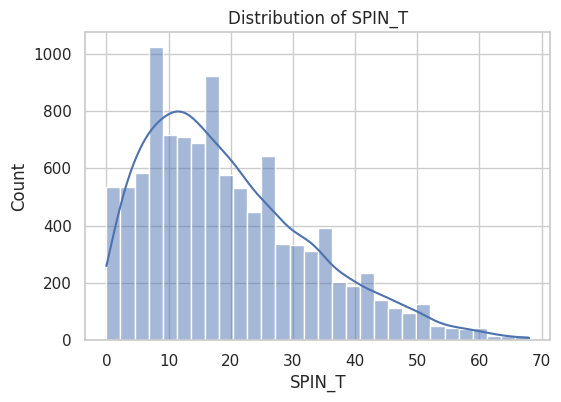

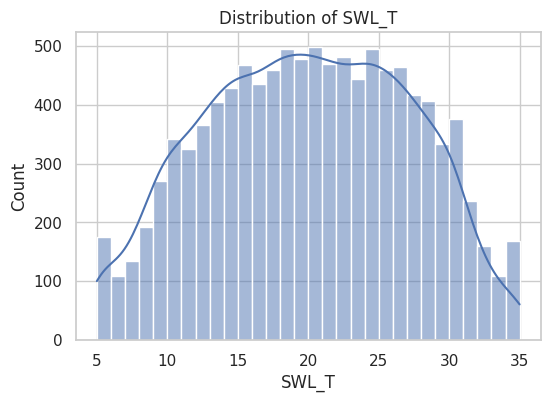

In [39]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_pd[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

**Interpretation:** The histogram confirms the right skew in `GAD_T` — most players cluster at low anxiety scores, with a long tail toward higher scores. `SPIN_T` shows a similar right-skewed pattern, while `SWL_T` is closer to symmetric, and `Hours` is also right-skewed with a long tail of high-playtime outliers.

### EDA Question 2: How much do anxiety, social anxiety, and life satisfaction scores vary, and are there extreme cases?

Here we examine dispersion (standard deviation, variance) and use boxplots to spot outliers and the spread of scores across players.

## Measures of Dispersion

In [40]:
# Standard deviation
std_values = df_pd[numeric_cols].std()
print("STANDARD DEVIATION\n", std_values)

# Variance
var_values = df_pd[numeric_cols].var()
print("\nVARIANCE\n", var_values)

STANDARD DEVIATION
 Hours     13.123689
GAD_T      4.673519
SPIN_T    13.386069
SWL_T      7.189745
dtype: float64

VARIANCE
 Hours     172.231211
GAD_T      21.841784
SPIN_T    179.186848
SWL_T      51.692438
dtype: float64


**Interpretation:** `GAD_T` has a standard deviation of about 4.67 on a 0-21 scale, showing considerable spread. `SPIN_T` is even more spread out (std ~13.39 on a 0-68 scale), while `SWL_T` is comparatively tighter (std ~7.19 on a 5-35 scale) — life satisfaction scores cluster more closely than anxiety-related scores.

### Boxplot

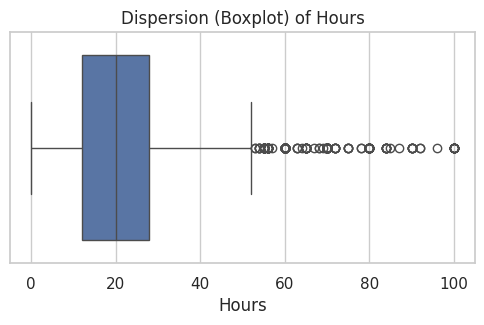

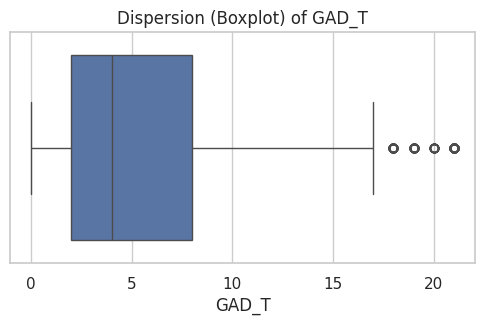

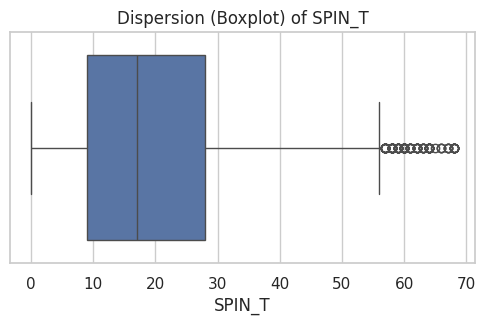

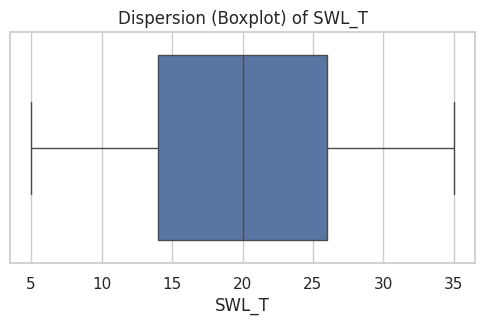

In [41]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_pd[col])
    plt.title(f"Dispersion (Boxplot) of {col}")
    plt.show()

**Interpretation:** The boxplots show `GAD_T` and `SPIN_T` both have upper-tail outliers — a subset of players reporting unusually high anxiety and social anxiety. `Hours` has the most extreme outliers, consistent with a few players reporting very high weekly playtime even after removing values of 100+ hours.

### EDA Question 3: Is anxiety associated with social anxiety, life satisfaction, or hours played?

To explore possible factors behind anxiety, we compute correlations between `GAD_T` and the other numeric variables, using both Pearson (linear) and Spearman (rank-based) measures to check robustness.

## Correlation Analysis (General)

          Hours     GAD_T    SPIN_T     SWL_T
Hours   1.00000  0.093260  0.093810 -0.131280
GAD_T   0.09326  1.000000  0.452834 -0.397335
SPIN_T  0.09381  0.452834  1.000000 -0.313510
SWL_T  -0.13128 -0.397335 -0.313510  1.000000


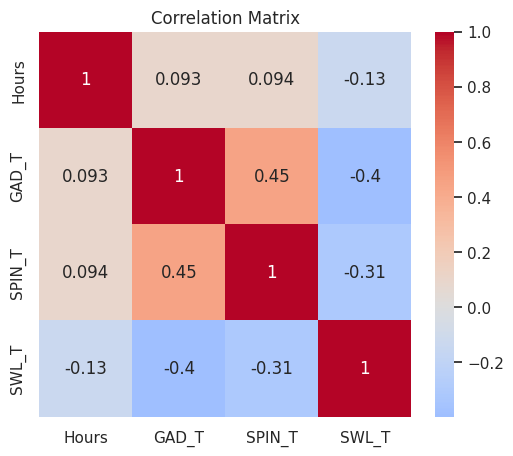

In [42]:
corr_matrix = df_pd[numeric_cols].corr()

print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

**Interpretation:** `GAD_T` correlates moderately with `SPIN_T` (r ~0.45) and moderately negatively with `SWL_T` (r ~-0.40), but only weakly with `Hours` (r ~0.09). This suggests anxiety is more closely tied to other psychological factors than to time spent gaming.

### Pearson Correlation (Linear Relationship)

PEARSON CORRELATION

          Hours     GAD_T    SPIN_T     SWL_T
Hours   1.00000  0.093260  0.093810 -0.131280
GAD_T   0.09326  1.000000  0.452834 -0.397335
SPIN_T  0.09381  0.452834  1.000000 -0.313510
SWL_T  -0.13128 -0.397335 -0.313510  1.000000


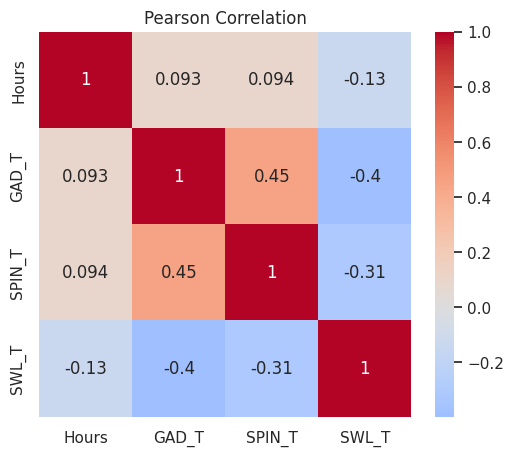

In [43]:
pearson_corr = df_pd[numeric_cols].corr(method="pearson")
print("PEARSON CORRELATION\n")
print(pearson_corr)

plt.figure(figsize=(6,5))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Pearson Correlation")
plt.show()

**Interpretation:** Under Pearson correlation, `GAD_T` shows a moderate positive linear relationship with `SPIN_T` (0.45) and a moderate negative linear relationship with `SWL_T` (-0.40). The relationship with `Hours` is negligible (0.09).

### Spearman Correlation (Rank-based Relationship)

SPEARMAN CORRELATION

           Hours     GAD_T    SPIN_T     SWL_T
Hours   1.000000  0.065386  0.086600 -0.117479
GAD_T   0.065386  1.000000  0.433931 -0.391212
SPIN_T  0.086600  0.433931  1.000000 -0.305564
SWL_T  -0.117479 -0.391212 -0.305564  1.000000


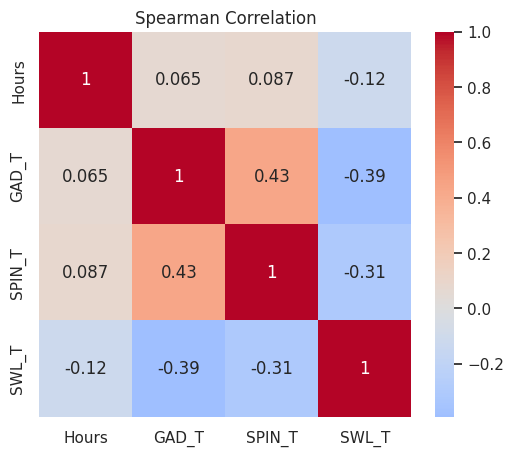

In [44]:
spearman_corr = df_pd[numeric_cols].corr(method="spearman")
print("SPEARMAN CORRELATION\n")
print(spearman_corr)

plt.figure(figsize=(6,5))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation")
plt.show()

**Interpretation:** Spearman correlations are close to the Pearson values (e.g. `GAD_T`-`SPIN_T`: 0.43 vs 0.45), indicating these relationships are fairly monotonic and not driven by a few extreme outliers or strong nonlinearity.

### Pearson vs Spearman Comparison

In [45]:
comparison = pd.DataFrame({
    "Pearson": df_pd[numeric_cols].corr(method="pearson").unstack(),
    "Spearman": df_pd[numeric_cols].corr(method="spearman").unstack()
})

print(comparison)

                Pearson  Spearman
Hours  Hours   1.000000  1.000000
       GAD_T   0.093260  0.065386
       SPIN_T  0.093810  0.086600
       SWL_T  -0.131280 -0.117479
GAD_T  Hours   0.093260  0.065386
       GAD_T   1.000000  1.000000
       SPIN_T  0.452834  0.433931
       SWL_T  -0.397335 -0.391212
SPIN_T Hours   0.093810  0.086600
       GAD_T   0.452834  0.433931
       SPIN_T  1.000000  1.000000
       SWL_T  -0.313510 -0.305564
SWL_T  Hours  -0.131280 -0.117479
       GAD_T  -0.397335 -0.391212
       SPIN_T -0.313510 -0.305564
       SWL_T   1.000000  1.000000


**Interpretation:** Since Pearson and Spearman values are consistently close across all pairs, the linear correlation estimates appear reliable. This answers EDA Question 3: social anxiety and life satisfaction appear more strongly associated with anxiety than weekly hours played, making them promising factors to test formally in MCO2.

# References
- *[Kaggle Dataset Link](https://www.kaggle.com/datasets/divyansh22/online-gaming-anxiety-data/data)*
- *[Original Paper](https://osf.io/preprints/psyarxiv/mfajz_v1)*
- *[Questionnaire](https://osf.io/vnbxk/files/vyr5f?view_only=4c54da075e164ea2a5329f5669d03c41)*